# Customer Churn Prediction

## Machine Learning Modeling and Prediction

### Author: Aaron Thomas

## Table of Contents

<ol>
    <li>Introduction</li>
        <ol>
            <li>Overview</li>
        </ol>
    <li>Data Loading</li>
        <ol>
            <li>Import Libraries</li>
            <li>Load Preprocessed Data</li>
            <li>Data Shape Check</li>
        </ol>
    <li>Model Training and Evaluation</li>
        <ol>
            <li>Logistic Regression</li>
            <li>Random Forest Classifier</li>
            <li>XGBoost Classifier</li>
            <li>Support Vector Machine (SVM)</li>
        </ol>
    <li>Model Comparison</li>
        <ol>
            <li>Summary of Model Performance</li>
            <li>ROC Curve Comparison</li>
            <li>Best Model Selection</li>
        </ol>
    <li>Hyperparameter Tuning</li>
    <li>Final Model Evaluation</li>
        <ol>
            <li>Final Evaluation Metrics</li>
            <li>Final Evaluation Confusion Matrix</li>
            <li>Final Evaluation ROC Curve</li>
        </ol>
    <li>Model Insights</li>
        <ol>
            <li>Feature Importance</li>
            <li>Business Implications</li>
            <li>Limitations</li>
        </ol>
    <li>Save the Model</li>
    <li>Conclusion</li>
        <ol>
            <li>Summary of Findings</li>
        </ol>
</ol>

## 1) Introduction

### 1.1) Overview

The purpose of this notebook is to build and evaluate machine learning models to predict customer churn. We will load the preprocessed data, train several classification models, evaluate their performance, and compare their results. Finally, we will perform hyperparameter tuning on the best-performing model and save it for future use.

## 2) Data Loading

In the previous notebook, the data was saved in four separate files: `X_train.csv`, `X_test.csv`, `y_train.csv`, and `y_test.csv`. We will load these files into pandas DataFrames to prepare for model training.

### 2.1) Import Libraries

The following libraries will be used for data manipulation, model training, evaluation, visualization, and saving the model:

In [11]:
import pandas as pd
import numpy as np
import joblib
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2) Load Preprocessed Data

To load the training and testing datasets, the following code is used:

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  # Convert to Series
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()  # Convert to Series


As shown above, the .squeeze() method is applied to the target variable DataFrames to convert them into Series, which is the expected format for most machine learning algorithms. After running this code, we will have `X_train`, `X_test`, `y_train`, and `y_test` ready for model training and evaluation.

## 2.3 Data Shape Check

The following code checks the shapes of the loaded datasets to ensure they are correctly loaded and ready for modeling:

In [30]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8278, 34), (8278,), (1409, 34), (1409,))

## 3) Model Training and Evaluation

For this section, various machine learning models will be trained and evaluated on the training and testing datasets. The models include:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- Support Vector Machine (SVM)

### 3.1) Logistic Regression

In [3]:
def log_reg_model(X_train, y_train, X_test, y_test):
    log_model = LogisticRegression(max_iter=1000,
                                   random_state=42
                                   )
    log_model.fit(X_train, y_train)
    y_pred = log_model.predict(X_test)
    y_prob = log_model.predict_proba(X_test)[ :, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Logistic Regression Performance:")
    print("Accuracy: ", round(acc, 4))
    print("Precision: ", round(prec, 4))
    print("Recall: ", round(rec, 4))
    print("F1-Score: ", round(f1, 4))
    print("ROC AUC: ", round(roc_auc, 4))
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion Matrix
    cm_log = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Logistic Regression Confusion Matrix')
    plt.show()

    return log_model, acc, prec, rec, f1, roc_auc

### 3.2) Random Forest Classifier

In [4]:
def rand_for_model(X_train, y_train, X_test, y_test):
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        oob_score=True #This enables out-of-bag score for performance estimation
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[ :, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Random Forest Performance:")
    print("Accuracy: ", round(acc, 4))
    print("Precision: ", round(prec, 4))
    print("Recall: ", round(rec, 4))
    print("F1-Score: ", round(f1, 4))
    print("ROC AUC: ", round(roc_auc, 4))
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion matrix
    cm_rf = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn']
                )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Random Forest Confusion Matrix')
    plt.show()

    return rf_model, acc, prec, rec, f1, roc_auc   

### 3.3) XGBoost Classifier

In [5]:
def xg_boost_model(X_train, y_train, X_test, y_test):
    xgb_model = XGBClassifier(
        n_estimators = 100,
        learning_rate = 0.1,
        random_state = 42,
        max_depth = 5
    )
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[ :, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)


    print("XGBoost Performance:")
    print("Accuracy: ", round(acc, 4))
    print("Precision: ", round(prec, 4))
    print("Recall: ", round(rec, 4))
    print("F1-Score: ", round(f1, 4))
    print("ROC AUC: ", round(roc_auc, 4))
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion Matrix
    cm_xgb = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('XGBoost Confusion Matrix')
    plt.show()

    return xgb_model, acc, prec, rec, f1, roc_auc

### 3.4) Support Vector Machine (SVM)

In [ ]:
def support_vector_machine_model(X_train, y_train, X_test, y_test):
    svm_clf =SVC(kernel='rbf', # Radial Basis Function kernel for non-linear classification
                   probability=True, # Enable probability estimates for ROC AUC calculation
                   random_state=42,
                   C=1.0, 
                   gamma='scale' # Default gamma value for SVM, scaled by the number of features
    )
    svm_clf.fit(X_train, y_train)
    y_pred = svm_clf.predict(X_test)
    y_prob = svm_clf.predict_proba(X_test)[ :, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    print("SVM Performance:")
    print("Accuracy: ", round(acc, 4))
    print("Precision: ", round(prec, 4))
    print("Recall: ", round(rec, 4))
    print("F1-Score: ", round(f1, 4))
    print("ROC AUC: ", round(roc_auc, 4))
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


    # Confusion Matrix
    cm_svm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('SVM Confusion Matrix')
    plt.show()

    return svm_clf, acc, prec, rec, f1, roc_auc

## 4) Model Comparison

This section will compare the performance of the different models using metrics such as accuracy, precision, recall, F1-score, and ROC AUC. A summary table will be created to visualize the results and determine which model performs best on the customer churn prediction task.

### 4.1) Summary of Model Performance

Logistic Regression Performance:
Accuracy:  0.7587
Precision:  0.5354
Recall:  0.6872
F1-Score:  0.6019
ROC AUC:  0.8265
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.83      1035
       Churn       0.54      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.76      0.77      1409



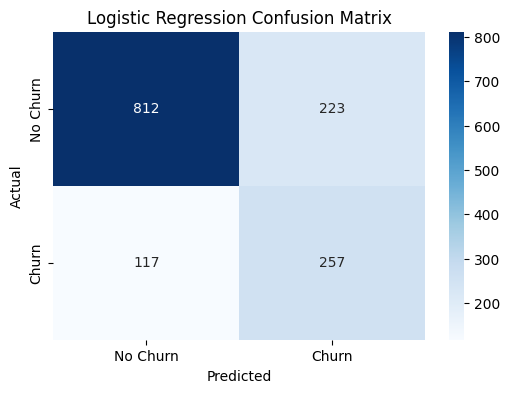

Random Forest Performance:
Accuracy:  0.758
Precision:  0.5374
Recall:  0.6337
F1-Score:  0.5816
ROC AUC:  0.8222
              precision    recall  f1-score   support

    No Churn       0.86      0.80      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.76      1409



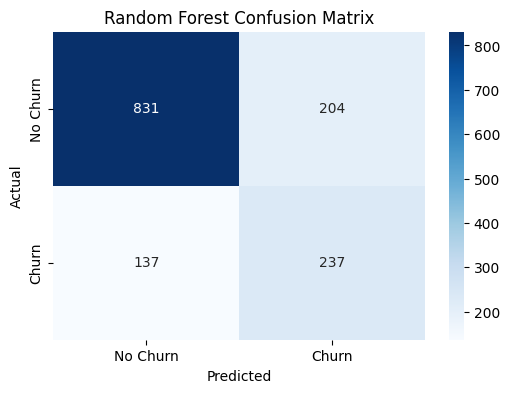

XGBoost Performance:
Accuracy:  0.7523
Precision:  0.5243
Recall:  0.7219
F1-Score:  0.6074
ROC AUC:  0.8294
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1035
       Churn       0.52      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



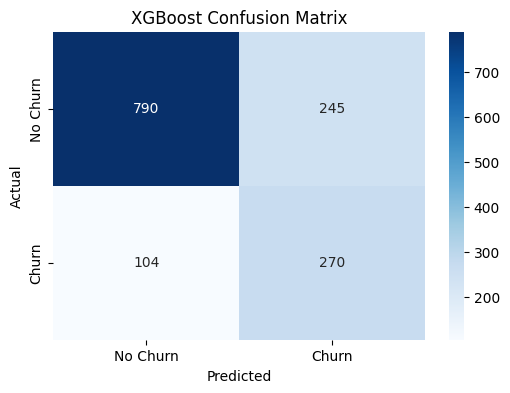

SVM Performance:
Accuracy:  0.7559
Precision:  0.531
Recall:  0.6872
F1-Score:  0.5991
ROC AUC:  0.8215
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.82      1035
       Churn       0.53      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.76      1409



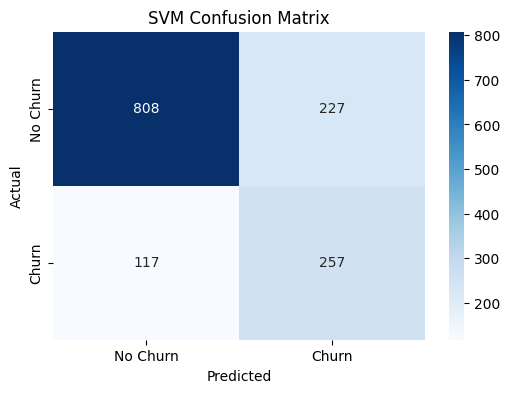

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.76,0.54,0.69,0.60,0.83
Random Forest,0.76,0.54,0.63,0.58,0.82
XGBoost,0.75,0.52,0.72,0.61,0.83
SVM,0.76,0.53,0.69,0.60,0.82


In [8]:
log_model, log_acc, log_prec, log_rec, log_f1, log_roc_auc = log_reg_model(X_train, y_train, X_test, y_test)
rf_model, rf_acc, rf_prec, rf_rec, rf_f1, rf_roc_auc = rand_for_model(X_train, y_train, X_test, y_test)
xgb_model, xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_roc_auc = xg_boost_model(X_train, y_train, X_test, y_test)
svm_model, svm_acc, svm_prec, svm_rec, svm_f1, svm_roc_auc = support_vector_machine_model(X_train, y_train, X_test, y_test)

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [log_acc, rf_acc, xgb_acc, svm_acc],
    'Precision': [log_prec, rf_prec, xgb_prec, svm_prec],
    'Recall': [log_rec, rf_rec, xgb_rec, svm_rec],
    'F1-Score': [log_f1, rf_f1, xgb_f1, svm_f1],
    'ROC AUC': [log_roc_auc, rf_roc_auc, xgb_roc_auc, svm_roc_auc]
}

pd.DataFrame(results).set_index('Model').round(2)

Looking at the results, the following observations can be made for each model:
- **Logistic Regression**:
    - The model achieved an accuracy of 0.76, indicating that it correctly predicted 76% of instances in the test set. 
    - The precision of the model is 0.54, which means that when the model predicts a customer will churn, it is correct 54% of the time.
    - The recall is 0.69, suggesting that the model correctly identifies 69% of the actual churners.
    - The F1-score of 0.60 shows a moderate balance between precision and recall, indicating that the model is reasonably effective at predicting churn but may have room for improvement.
    - The ROC AUC score is 0.83, which indicates that the model has good discriminatory ability between churners and non-churners.
- **Random Forest Classifier**:
    - The model achieved an accuracy of 0.76, similar to Logistic Regression, indicating that it correctly predicted 76% of instances in the test set.
    - The precision of the model is 0.54, which is the same as Logistic Regression, meaning that when the model predicts a customer will churn, it is correct 54% of the time.
    - The recall is 0.63, suggesting that the model correctly identifies 63% of the actual churners.
    - The F1-score of 0.58 shows a slightly lower balance between precision and recall, indicating that the model may be less effective at predicting churn.
    - The ROC AUC score is 0.82, which indicates that the model has good discriminatory ability, but slightly lower.
- **XGBoost Classifier**:
    - The model achieved an accuracy of 0.75, indicating that it correctly predicted 75% of instances in the test set.
    - The precision of the model is 0.52, which means that when the model predicts a customer will churn, it is correct 52% of the time.
    - The recall is 0.72, suggesting that the model correctly identifies 72% of the actual churners.
    - The F1-score of 0.61 shows a moderate balance between precision and recall, indicating that the model is reasonably effective at predicting churn.
    - The ROC AUC score is 0.83, indicating that the model has good discriminatory ability, similar to Logistic Regression.
- **Support Vector Machine (SVM)**:
    - The model achieved an accuracy of 0.76, indicating that it correctly predicted 76% of instances in the test set.
    - The precision of the model is 0.54, which means that when the model predicts a customer will churn, it is correct 54% of the time.
    - The recall is 0.69, suggesting that the model correctly identifies 69% of the actual churners.
    - The F1-score is 0.60, also showing a moderate balance between precision and recall.
    - The ROC AUC score is 0.82, indicating that the model has good discriminatory ability, but slightly lower than Logistic Regression and XGBoost.


### 4.2) ROC Curve Comparison

The purpose of analyzing the ROC curves is to visually compare the performance of the different models across different thresholds. The ROC curve plots the true positive rate (recall) against the false positive rate at various threshold settings. The area under the ROC curve (AUC) provides a single metric to summarize the model's performance, with higher values indicating better discrimination between classes. By comparing the ROC curves of the models, we can identify which model has the best trade-off between sensitivity and specificity for predicting customer churn. The following code plots and compares the ROC curves for all four models:

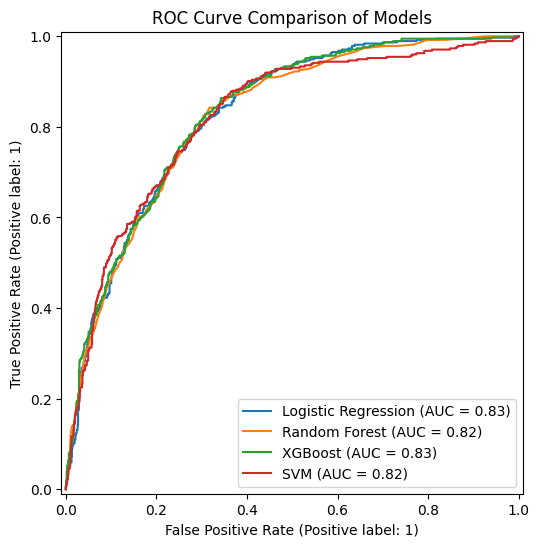

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
RocCurveDisplay.from_predictions(y_test, log_model.predict_proba(X_test)[:, 1], name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_model.predict_proba(X_test)[:, 1], name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_model.predict_proba(X_test)[:, 1], name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_test, svm_model.predict_proba(X_test)[:, 1], name='SVM', ax=ax)
plt.title('ROC Curve Comparison of Models')
plt.show()

Based on the ROC curve plot above, it can be seen that the Logistic Regression and XGBoost models have the highest AUC scores. This indicates that they are best at distinguishing between customers who will churn and those who will not churn. The Random Forest and SVM models are slightly lower by 0.01, indicating that they are less effective at distinguishing between the two classes. Overall, the ROC curve analysis suggests that Logistic Regression and XGBoost are the most promising models for predicting customer churn in this dataset.

### 4.3) Best Model Selection

Looking at each model, the best model for predicting customer churn appears to be the XGBoost Classifier. While its accuracy is slightly lower compared to the other three models, it has the highest recall and F-1 score, as well as having a high ROC AUC score (same as Logistic Regression). This suggests that XGBoost is better at identifying actual churners, which is crucial for this type of problem where the cost of missing a churner can be high. Therefore, XGBoost will be selected as the best model for further hyperparameter tuning and final evaluation.

## 5) Hyperparameter Tuning

The purpose of hyperparameter tuning is to optimize the performance of the best selected model (XGBoost Classifier) by finding the best combination of hyperparameters. Hyperparameters are set before the start of the learning process and can significantly impact the performance of the model. By using the RandomizedSearchCV method, this process will efficiently search through a specified hyperparameter space to find optimal values for the XGBoost model, which can lead to improved performance in predicting customer churn. The following code will be used to perform hyperparameter tuning on the XGBoost Classifier:

In [12]:
model = XGBClassifier(random_state=42, eval_metric='logloss')

parameters = {
    'n_estimators': [100, 200, 300, 400], # Number of trees in the ensemble
    'max_depth': [3, 4, 5, 6, 7], # Maximum depth of each tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Step size shrinkage used in update to prevent overfitting
    'subsample': [0.6, 0.7, 0.8, 1.0], # Subsample ratio of the training instances to prevent overfitting
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0] # Subsample ratio of columns when constructing each tree to prevent overfitting
}


xgb_tuned = RandomizedSearchCV(
    estimator=model,
    param_distributions=parameters,
    n_iter=50, # Number of parameter settings that are sampled
    scoring= 'recall', # Metric to optimize - recall is chosen to prioritize identifying actual churners
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores for parallel processing
    verbose=1, # Print progress during tuning
    random_state=42
)

xgb_tuned.fit(X_train, y_train)
print("Best Parameters:", xgb_tuned.best_params_)
print("Best CV Recall Score:", round(xgb_tuned.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV Recall Score: 0.8683


Based on the results of the hyperparameter tuning, the best parameters for the XGBoost Classifier were found to be:
- subsample: 1.0
- n_estimators: 300
- max_depth: 7
- learning_rate: 0.05
- colsample_bytree: 1.0

In addition, the best CV recall score was about 0.87, which indicates that the tuned XGBoost model is even better at identifying actual churners compared to the default parameters. This improvement in recall is crucial for customer churn prediction, as it helps to minimize the number of missed churners, allowing for more effective retention strategies.

After tuning the XGBoost model, the next step will be to evaluate its performance on the test set using the best hyperparameters found. This will provide insight into how well the tuned model generalizes to unseen data and whether it has improved compared to the default parameters. The following code will be used to evaluate the tuned XGBoost model on the test set:

In [13]:
best_xgb = xgb_tuned.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))
print("Tuned XGBoost ROC AUC: ", round(roc_auc_score(y_test, y_prob_tuned), 4))

              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.53      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409

Tuned XGBoost ROC AUC:  0.8123


Based on the results for the test set evaluation, the following observations can be made for the tuned XGBoost model:
- The accuracy is 0.75, which is the same as the default XGBoost model, indicating that the overall correctness of predictions has not changed.
- The precision is 0.53, which is slightly higher than the default model's precision of 0.52, suggesting a small improvement in the model's ability to correctly identify churners when it predicts a customer will churn.
- The recall is 0.65, which is slightly lower than the default model's recall of 0.72, indicating that the tuned model may be missing more actual churners compared to the default parameters.
- The F1-score is 0.58, which is slightly lower than the default model's F1-score of 0.61, suggesting that the balance between precision and recall has not improved with tuning.
- The ROC AUC score is 0.81, which is slightly lower than the default model's ROC AUC of 0.83. This indicates that the tuned model has slightly less discriminatory ability compared to the default parameters. 

Overall, while cross-validation suggested a recall of 0.87, the tuned model's test recall of 0.65 indicated the model overfitted to the training data and did not generalize well to the test set. Due to this, another round of tuning will be conducted to further optimize the XGBoost model and attempt to improve its performance on the test set:


In [14]:
model_2 = XGBClassifier(random_state=42, eval_metric='logloss')

parameters_tuned = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5], # Maximum depth of each tree - shallower
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage used in update to prevent overfitting - smaller learning rates
    'subsample': [0.6, 0.7, 0.8], # Subsample ratio of the training instances to prevent overfitting - smaller subsample ratios
    'colsample_bytree': [0.6, 0.7, 0.8] # Subsample ratio of columns when constructing each tree to prevent overfitting - smaller column subsample ratios
}

xgb_tuned_2 = RandomizedSearchCV(
    estimator=model_2,
    param_distributions=parameters_tuned,
    n_iter=50, # Number of parameter settings that are sampled
    scoring= 'recall', # Metric to optimize - recall is chosen to prioritize identifying actual churners
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores for parallel processing
    verbose=1, # Print progress during tuning
    random_state=42
)

xgb_tuned_2.fit(X_train, y_train)
print("Best Parameters (Round 2):", xgb_tuned_2.best_params_)
print("Best CV Recall Score (Round 2):", round(xgb_tuned_2.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters (Round 2): {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Recall Score (Round 2): 0.8555


Based on the results above, the best parameters for the second round of hyperparameter tuning on the XGBoost Classifier were found to be:
- subsample: 0.6
- n_estimators: 300
- max_depth: 5
- learning_rate: 0.1
- colsample_bytree: 0.8

The best CV recall score for this second round was about 0.86, which is slightly lower than the first round of tuning. However, it will be important to evaluate this second tuned model on the test set to see if there is any improvement in performance compared to the first round of tuning and the default parameters. The following code will be used to evaluate the second tuned XGBoost model on the test set:

In [15]:
best_xgb_model_2 = xgb_tuned_2.best_estimator_

y_pred_tuned_2 = best_xgb_model_2.predict(X_test)
y_prob_tuned_2 = best_xgb_model_2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned_2, target_names=['No Churn', 'Churn']))
print("Tuned XGBoost ROC AUC (Round 2): ", round(roc_auc_score(y_test, y_prob_tuned_2), 4))

              precision    recall  f1-score   support

    No Churn       0.86      0.80      0.83      1035
       Churn       0.53      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.70      1409
weighted avg       0.77      0.76      0.76      1409

Tuned XGBoost ROC AUC (Round 2):  0.8166


Based on the results for the second tuned XGBoost model, the following observations can be made:
- The accuracy is 0.76, which is slightly higher than the default model's accuracy of 0.75, indicating a small improvement in the overall correctness of predictions.
- The precision is 0.53, which is the same as the first round of tuning and slightly higher than the default model's precision of 0.52, suggesting that the model's ability to correctly identify churners when it predicts a customer will churn has not changed.
- The recall is 0.63, which is lower than the default model's recall and slightly lower than the first round of tuning, indicating that this second tuned model may be missing more actual churners compared to both the default parameters and the first round of tuning.
- The F1-score is 0.58, which is the same as the first round of tuning and slightly lower than the default model's F1-score of 0.61, suggesting that the balance between precision and recall has not improved with this second round of tuning.
- The ROC AUC score is about 0.82, which is slightly higher than the first round of tuning but still slightly lower than the default model.

Overall, while the second round of hyperparameter tuning resulted in a slight improvement in accuracy and ROC AUC compared to the first round, it did not have improved recall or F1-score.

## 6) Final Model Evaluation

In the previous section, two rounds of hyperparameter tuning were conducted on the XGBoost Classifier to optimize its performance for predicting customer churn. The results from both rounds of tuning were evaluated on the test set, and while there were some improvements in accuracy and ROC AUC, the recall and F1-score did not show significant improvement compared to the default parameters. Therefore, the final evaluation of the tuned XGBoost model will be based on the results from the default parameters, as it had better recall, F1-score, and ROC AUC compared to the tuned versions. The default XGBoost model will be considered the final model for predicting customer churn in this dataset, and its performance metrics will be reported as the final evaluation results.

### 6.1) Final Evaluation Metrics

The final evaluation metrics for the default XGBoost model is displayed using the following code:

In [29]:
# Run the final evaluation of the default XGBoost model on the test set
y_pred_final = xgb_model.predict(X_test)
y_prob_final = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))
print("Final XGBoost ROC AUC: ", round(roc_auc_score(y_test, y_prob_final), 4))

              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1035
       Churn       0.52      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Final XGBoost ROC AUC:  0.8294


### 6.2) Final Evaluation Confusion Matrix

The final confusion matrix for the default XGBoost model is displayed using the following code:

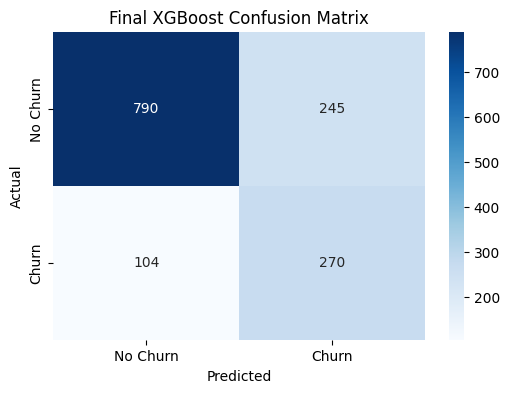

In [18]:
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final XGBoost Confusion Matrix')
plt.show()

### 6.3) Final Evaluation ROC Curve

The ROC curve for the default XGBoost model is displayed using the following code:

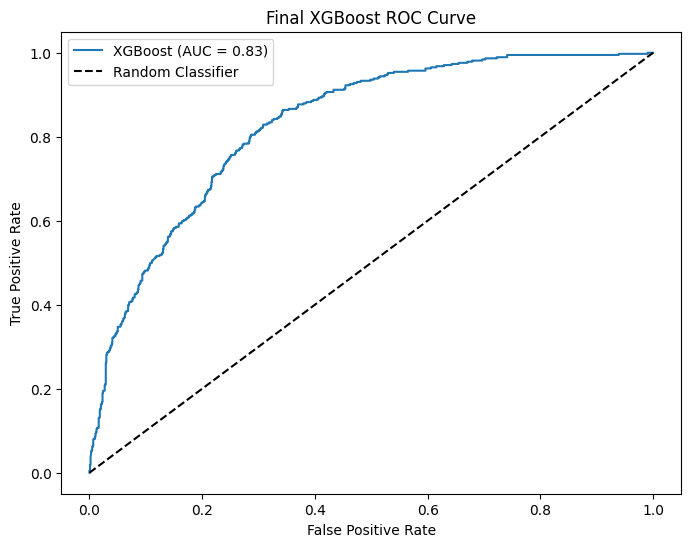

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='XGBoost (AUC = 0.83)')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final XGBoost ROC Curve')
plt.legend()
plt.show()

## 7) Model Insights

### 7.1) Feature Importance

The purpose of feature importance analysis is to identify which features play a significant role in predicting customer churn. By analyzing the feature importance scores from the XGBoost model, this can determine which features have the most influence on the model's predictions. In addition, this gives a better understanding of the factors that contribute to customer churn, which can be valuable for business decision-making and developing targeted retention strategies. The following code will be used to analyze and visualize the feature importance from the XGBoost model:

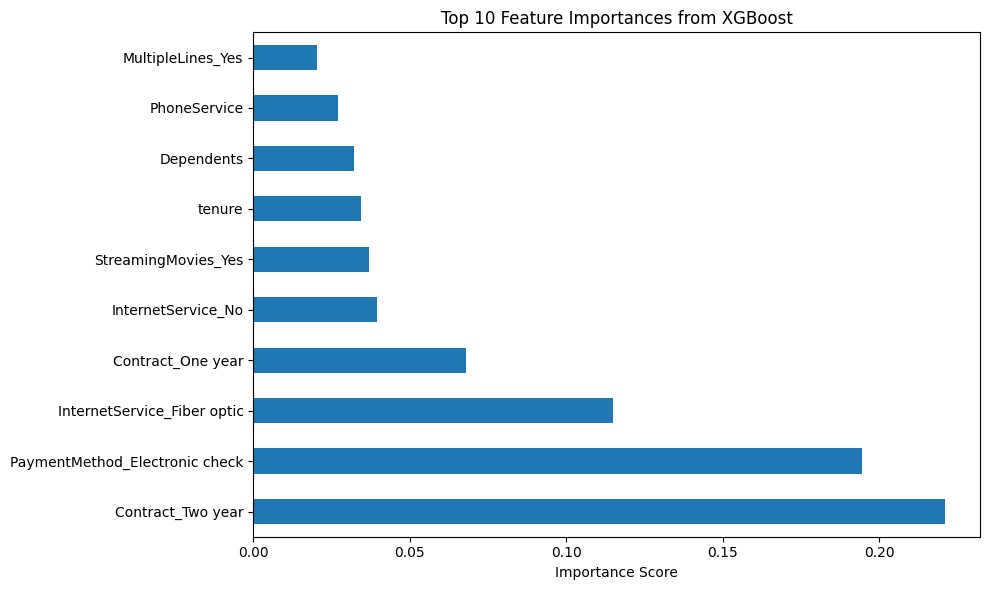

In [ ]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Feature Importances from XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 7.2) Business Insights

Based on the feature importance analysis, the following observations can be made regarding the factors that contribute to customer churn:

- `Contract_Two year`: Long-term contracts (two years) are less likely to churn compared to shorter-term contracts. To encourage customer retention in the first couple of months, the company should offer incentives or loyalty programs to reduce the likelihood of churn.
- `PaymentMethod_Electronic check`: Customers who use electronic checks as their payment method are more likely to churn compared to those who use other payment options. To address this, the company could consider offering alternatives like auto-pay or credit card payments, which may provide more convenience and reduce the likelihood of churn for these customers.
- `InternetService_Fiber optic`: Customers with fiber optic internet service are more likely to churn compared to those with other types of internet service. The company could investigate the reasons for customer dissatisfaction with fiber optic service and work on improving the quality of service or offering competitive pricing to retain these customers.
- `Contract_One year`: Customers with one-year contracts are more likely to churn compared to those with two-year contracts. Similar to the two-year contract insight, the company should focus on providing incentives and loyalty programs to customers in one-year contracts to encourage them to stay longer and reduce churn.
- `InternetService_No`: Customers without internet service are less likely to churn compared to those with internet service. The company could explore the reasons why customers without internet service are more loyal and consider offering similar benefits or features to customers with internet service to improve retention.
- `StreamingMovies_Yes`: Customers who have streaming movies service are more likely to churn compared to those who do not have this service. The company could investigate the reasons for customer dissatisfaction with the streaming movies service and work on improving the quality of service or offering competitive pricing to retain these customers.
- `tenure`: Customers with shorter tenure are more likely to churn compared to those with longer tenure. The company could focus on providing better customer support and engagement for new customers to help them feel more connected to the service and reduce the likelihood of churn in the early stages of their relationship with the company.

`Dependents`, `PhoneService`, and `MultipleLines` were found to have very low importance scores, suggesting that they may not be significant factors in predicting customer churn. The company could consider looking into these features further to confirm their lack of importance.

### 7.3) Limitations

It is important to acknowledge the limitations of the model and the analysis conducted. Some potential limitations include:
- The model utilized SMOTE for handling class imbalance, which may not always capture the true distribution of the minority class and could lead to overfitting on synthetic samples.
- The model was trained on a static (snapshot) dataset, which may not reflect changes in customer behavior or market conditions over time. This could limit the model's ability to generalize to future data.
- The fairness across demographic groups was not evaluated, which could lead to biased predictions if certain groups are underrepresented in the training data (e.g., `SeniorCitizen`).
- The feature importance analysis shows the correlation between features and the target variable, but not causation (i.e., it does not prove that certain features cause churn, only that they are associated with it). Further investigation would be needed to establish causal relationships.

## 8) Save the Model

### 8.1) Save the XGBoost Model

To save the final XGBoost model for future use, the following code can be used:

In [28]:
joblib.dump(xgb_model, '../models/xgb_model.pkl')

['../models/xgb_model.pkl']

## 9) Conclusion

### 9.1) Summary of Findings

Overall, the machine learning modeling process for predicting customer churn involved training and evaluating multiple classification models, with XGBoost being selected as the best-performing model based on recall, F1-score, and ROC AUC. Hyperparameter tuning was conducted to optimize the XGBoost model, but the default parameters ultimately provided better performance on the test set. The feature importance analysis provided insights into factors that contribute to customer churn (e.g., contract type, payment method, internet service), which can inform business strategies for customer retention. However, it is important to understand the limitations of the model and analysis, such as potential overfitting from SMOTE, lack of temporal generalization, and the need for further investigation to establish causal relationships between features and churn.